# Hypothesis 2:
We can classify a student as **"At-Risk" (Fail)** versus **"Safe" (Pass)** based heavily on their behavioral features like **absences**, **weekday alcohol**, **weekend alcohol**, **social**, **study time**, and **free time**

## Setup:

In [592]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [593]:
# We use this to map string enum values with integers
class EnumMapper:
    def __init__(self, values):
        # Get unique values and sort them so the mapping is deterministic
        unique_enums = sorted(list(set(values)))
        # Create bidirectional mappings
        self.string_to_index = {string_value: index + 1 for index, string_value in enumerate(unique_enums)}
        self.index_to_string = {index + 1: string_value for index, string_value in enumerate(unique_enums)}

    def update_map(self, custom_map: dict):
        # Deletes the old mapping entirely and creates a new one from the provided dictionary
        self.string_to_index = {}
        self.index_to_string = {}
        
        for index_value, string_value in custom_map.items():
            self.string_to_index[string_value] = index_value
            self.index_to_string[index_value] = string_value

    def transform_column(self, series: pd.Series) -> pd.Series:
        # Transforms string enums into indexes
        return series.map(self.string_to_index)

    def untransform_column(self, series: pd.Series) -> pd.Series:
        # Transforms indexes back into string enums
        return series.map(self.index_to_string)

    def transform_value(self, value: str) -> int:
        # Transforms a single string enum into its index
        if value not in self.string_to_index:
            raise ValueError(f"String enum '{value}' not recognized by the mapper")
        return self.string_to_index[value]

    def untransform_value(self, value: int) -> str:
        # Transforms a single index back into its string enum
        if value not in self.index_to_string:
            raise ValueError(f"Integer '{value}' not recognized by the mapper")
        return self.index_to_string[value]
    
    def mapping(self) :
        # Returns the mapping
        return self.index_to_string
    
    def count(self) -> int:
        # Returns the mapping value count
        return len(self.index_to_string)
    
    def info(self) -> dict:
        # Displays the mapping
        print("Enum Mapping Information:")
        if not self.string_to_index:
            print("No mappings found.")
        else:
            for index_value, string_value in self.index_to_string.items():
                print(f"String: '{string_value}'  ---->  Index: {index_value}")

            print("\n");
            
            for string_value, index_value in self.string_to_index.items():
                print(f"Index: {index_value}  ---->  String: '{string_value}'")

## Training Data:

In [594]:
training_data = pd.read_csv('../../data/train.csv',  usecols=['student_id', 'social', 'study_time', 'free_time', 'absences', 'weekday_alcohol', 'weekend_alcohol', 'final_grade'])
training_data = training_data[['student_id', 'social','study_time', 'free_time', 'absences', 'weekday_alcohol', 'weekend_alcohol', 'final_grade']]
training_data

,student_id,social,study_time,free_time,absences,weekday_alcohol,weekend_alcohol,final_grade
0,1,4,2 to 5 hours,3,6,1,1,6
1,2,3,2 to 5 hours,3,4,1,1,6
2,3,2,2 to 5 hours,3,10,2,3,10
3,4,2,5 to 10 hours,2,2,1,1,15
4,5,2,2 to 5 hours,3,4,1,2,10
...,...,...,...,...,...,...,...,...
390,391,4,2 to 5 hours,5,11,4,5,9
391,392,5,<2 hours,4,3,3,4,16
392,393,3,<2 hours,5,3,3,3,7
393,394,1,<2 hours,4,0,3,4,10


In [595]:
# Create passing status system
# Final grade that is max 20 points and we need 75% to pass
MAX_FINAL_GRADE = 20
PASS_THRESHOLD = 0.75 * MAX_FINAL_GRADE

print(f"Final Grade Max Points: {MAX_FINAL_GRADE}")
print(f"Pass Threshold Max Points: {PASS_THRESHOLD}")

Final Grade Max Points: 20
Pass Threshold Max Points: 15.0


In [596]:
study_time_mapper = EnumMapper(training_data['study_time'])

#Fix study time order, make it linear
study_time_mapper.update_map({ 1: '<2 hours', 2: '2 to 5 hours', 3: '5 to 10 hours', 4: '>10 hours'})

study_time_mapper.info()

Enum Mapping Information:
String: '<2 hours'  ---->  Index: 1
String: '2 to 5 hours'  ---->  Index: 2
String: '5 to 10 hours'  ---->  Index: 3
String: '>10 hours'  ---->  Index: 4


Index: 1  ---->  String: '<2 hours'
Index: 2  ---->  String: '2 to 5 hours'
Index: 3  ---->  String: '5 to 10 hours'
Index: 4  ---->  String: '>10 hours'


In [597]:
training_data['study_time'] = study_time_mapper.transform_column(training_data['study_time'])
training_data['pass_status'] = np.where(training_data['final_grade'] >= PASS_THRESHOLD, 'Safe', 'At-Risk')
training_data

,student_id,social,study_time,free_time,absences,weekday_alcohol,weekend_alcohol,final_grade,pass_status
0,1,4,2,3,6,1,1,6,At-Risk
1,2,3,2,3,4,1,1,6,At-Risk
2,3,2,2,3,10,2,3,10,At-Risk
3,4,2,3,2,2,1,1,15,Safe
4,5,2,2,3,4,1,2,10,At-Risk
...,...,...,...,...,...,...,...,...,...
390,391,4,2,5,11,4,5,9,At-Risk
391,392,5,1,4,3,3,4,16,Safe
392,393,3,1,5,3,3,3,7,At-Risk
393,394,1,1,4,0,3,4,10,At-Risk


In [598]:
# Define our features (X) and target (Y)
X = training_data[['study_time', 'free_time', 'social',  'absences', 'weekday_alcohol', 'weekend_alcohol']]
Y = training_data['pass_status']

# Split the data: 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = GaussianNB()

# Train the model
model.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = model.predict(X_test)

matrix = confusion_matrix(Y_test, Y_pred, labels=['Safe', 'At-Risk'])

# Print the detailed classification report
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

print("\n")
print("Confusion Matrix:")
print(matrix)
print("\n")

# Calculate overall accuracy
print(f"Model Accuracy: {accuracy_score(Y_test, Y_pred) * 100:.2f}%")


Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.76      0.85      0.80        59
        Safe       0.31      0.20      0.24        20

    accuracy                           0.68        79
   macro avg       0.53      0.52      0.52        79
weighted avg       0.64      0.68      0.66        79



Confusion Matrix:
[[ 4 16]
 [ 9 50]]


Model Accuracy: 68.35%


In [599]:
# Grouping the data to see the average behavior of each group
behavior_summary = training_data.groupby('pass_status')[['study_time', 'free_time','social', 'absences', 'weekday_alcohol', 'weekend_alcohol']].agg(['mean', 'std', 'median'])

# Displaying individual tables for clarity
print("Average Behavioral Metrics by Student Status")
display(behavior_summary.transpose())

Average Behavioral Metrics by Student Status


pass_status              At-Risk      Safe
study_time      mean    2.003106  2.178082
                std     0.818396  0.918067
                median  2.000000  2.000000
free_time       mean    3.223602  3.287671
                std     0.982559  1.073409
                median  3.000000  3.000000
social          mean    3.164596  2.863014
                std     1.113883  1.084167
                median  3.000000  3.000000
absences        mean    6.164596  3.698630
                std     8.490470  4.906586
                median  4.000000  2.000000
weekday_alcohol mean    1.543478  1.205479
                std     0.947026  0.498857
                median  1.000000  1.000000
weekend_alcohol mean    2.378882  1.904110
                std     1.303932  1.144606
                median  2.000000  1.000000

<Axes: title={'center': 'Confusion Matrix'}>

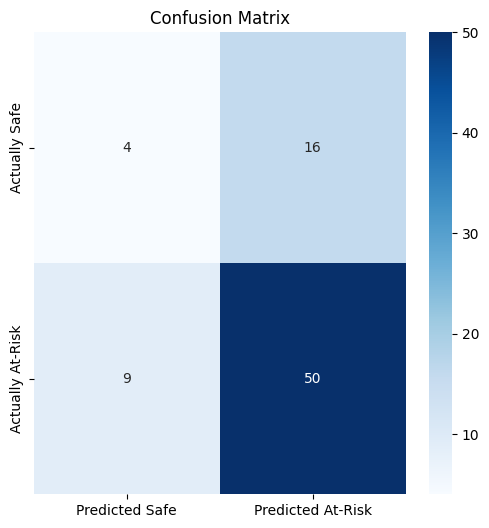

In [600]:
plt.figure(figsize=(6,6))
plt.title('Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Truth')
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Safe', 'Predicted At-Risk'], yticklabels=['Actually Safe', 'Actually At-Risk'])

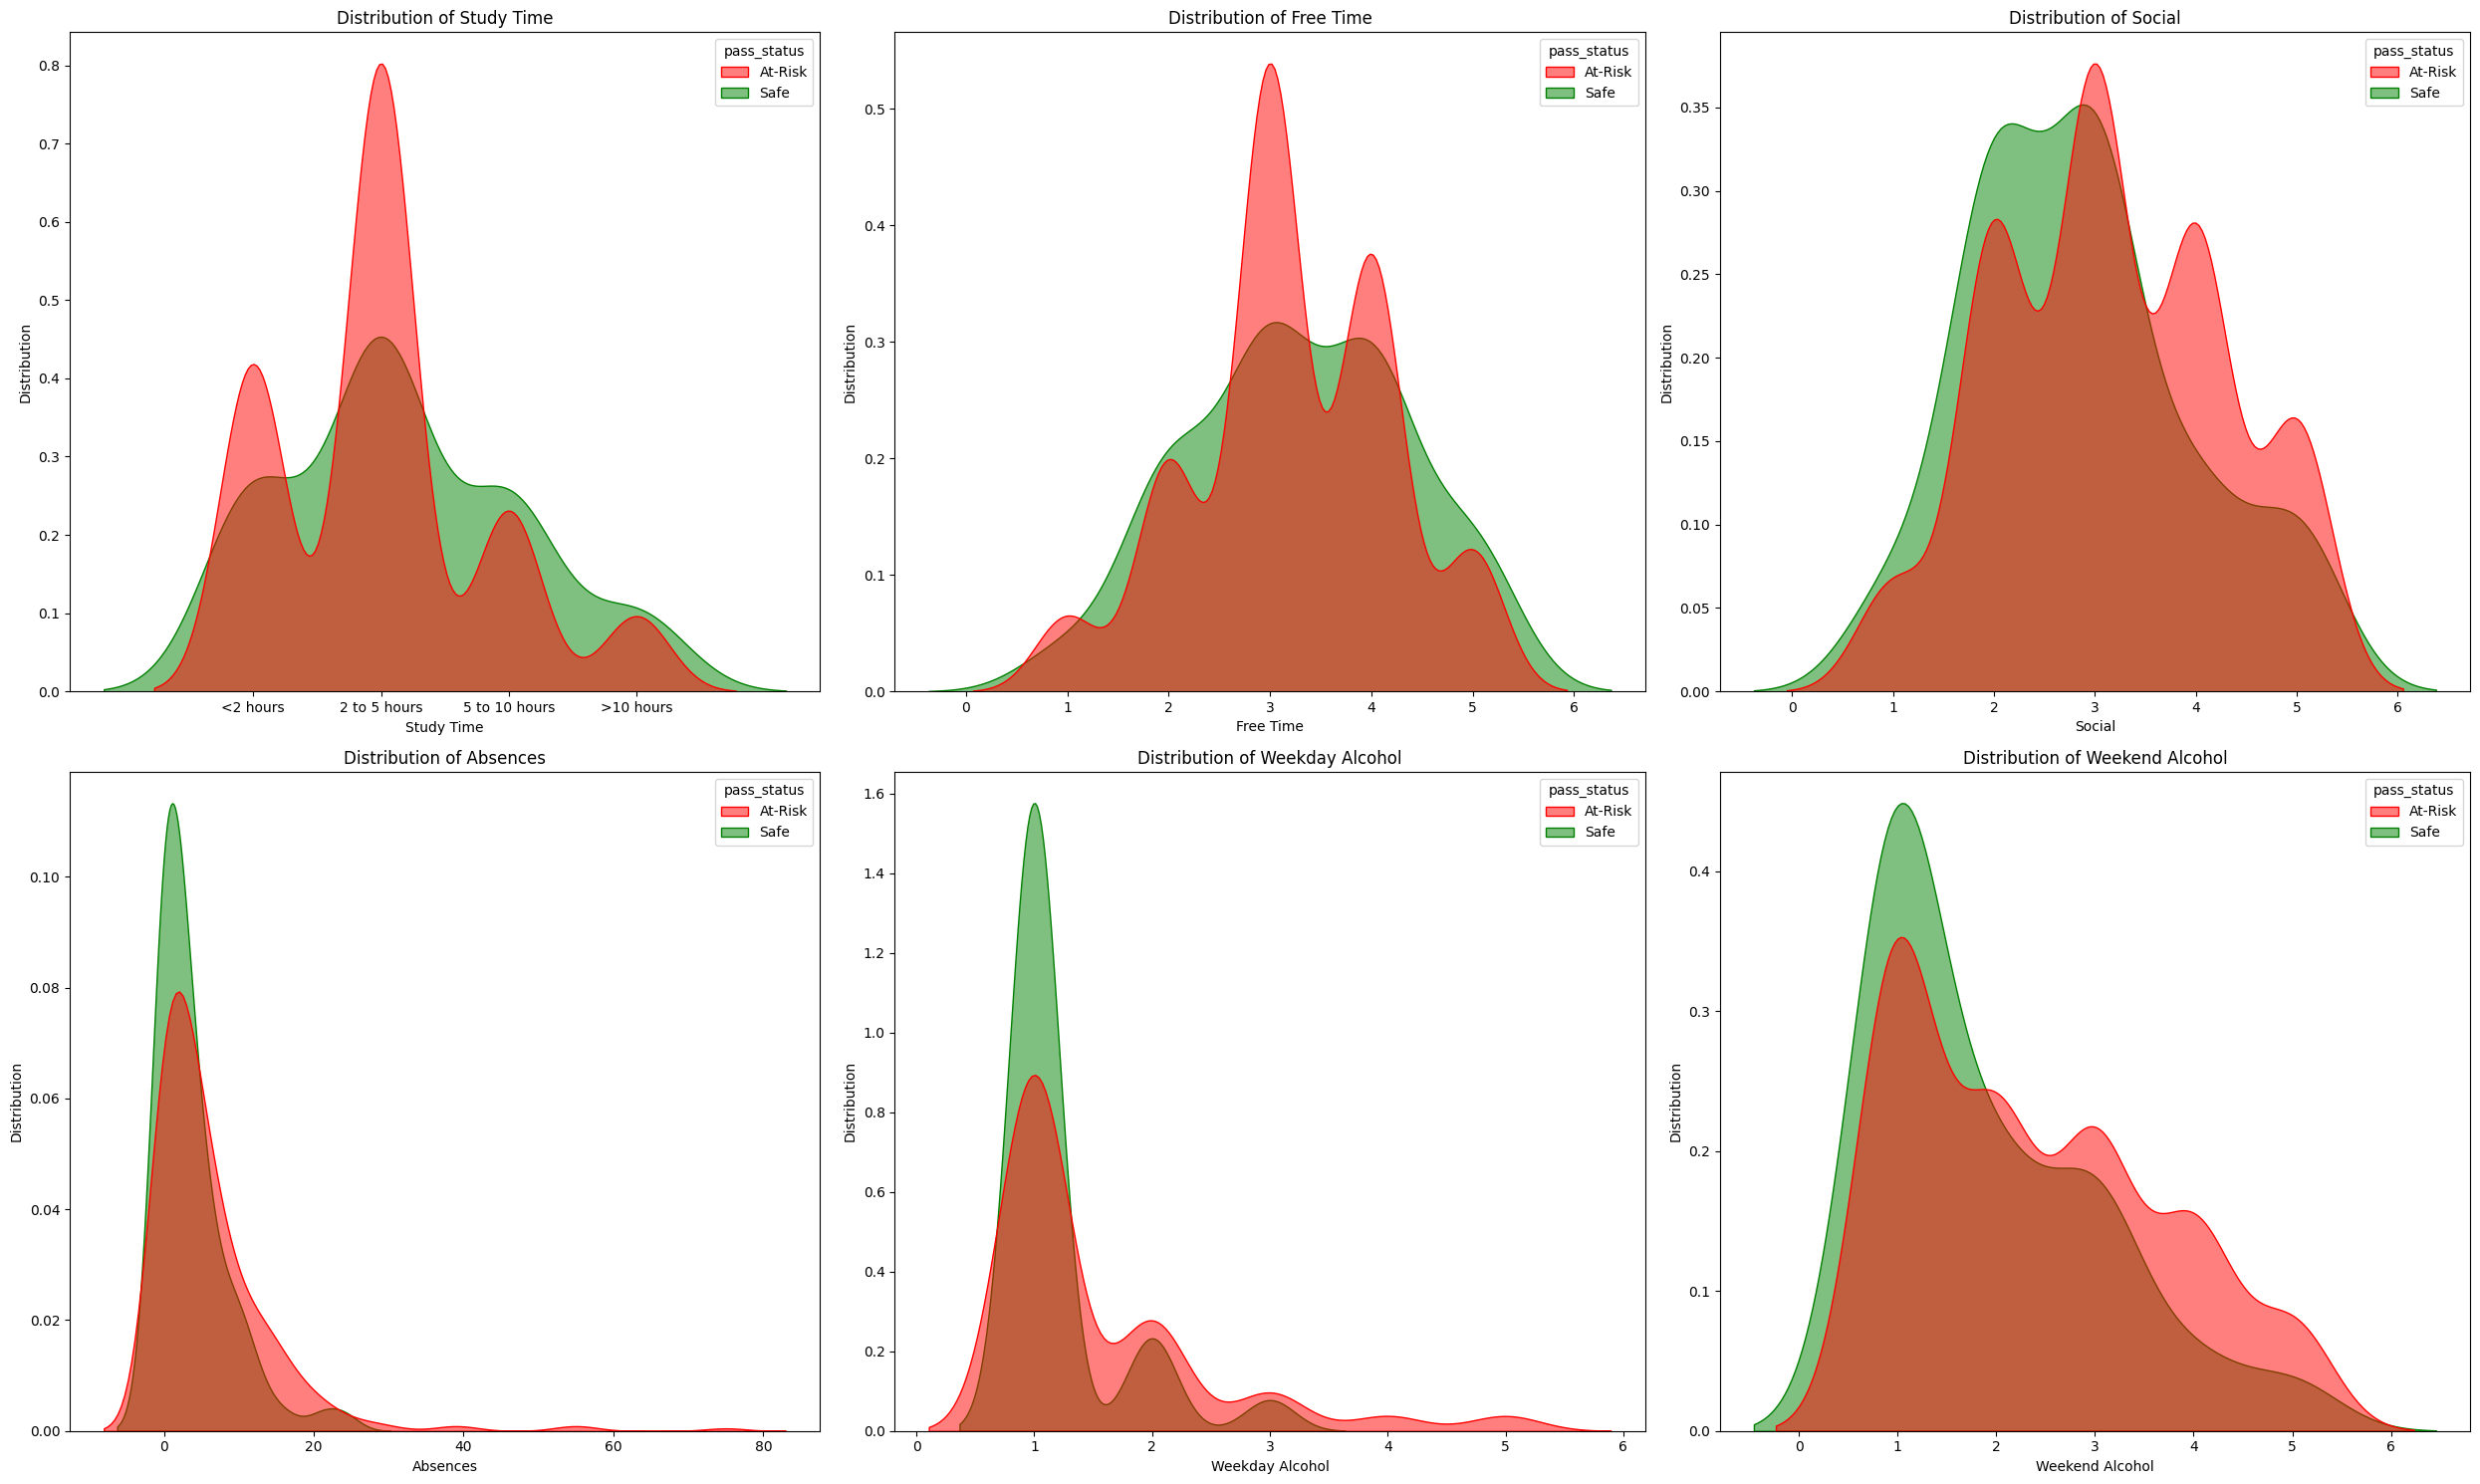

In [601]:
# Create a large figure to hold the plots
fig, axes = plt.subplots(2, 3, figsize=(25, 15))

# Diagram 1: Study Time
axes[0][0].set_title('Distribution of Study Time')
axes[0][0].set_xlabel("Study Time")
axes[0][0].set_ylabel("Distribution")
axes[0][0].set_xticks(list(study_time_mapper.mapping().keys()))
axes[0][0].set_xticklabels(list(study_time_mapper.mapping().values()))
sns.kdeplot(data=training_data, x='study_time', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][0])

# Diagram 2: Free Time
axes[0][1].set_title('Distribution of Free Time')
axes[0][1].set_xlabel("Free Time")
axes[0][1].set_ylabel("Distribution")
sns.kdeplot(data=training_data, x='free_time', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][1])

# Diagram 3: Social
axes[0][2].set_title('Distribution of Social')
axes[0][2].set_xlabel("Social")
axes[0][2].set_ylabel("Distribution")
sns.kdeplot(data=training_data, x='social', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][2])

# Diagram 4: Absences
axes[1][0].set_title('Distribution of Absences')
axes[1][0].set_xlabel("Absences")
axes[1][0].set_ylabel("Distribution")
sns.kdeplot(data=training_data, x='absences', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][0])

# Diagram 5: Weekday Alcohol
axes[1][1].set_title('Distribution of Weekday Alcohol')
axes[1][1].set_xlabel("Weekday Alcohol")
axes[1][1].set_ylabel("Distribution")
sns.kdeplot(data=training_data, x='weekday_alcohol', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][1])

# Diagram 6: Weekend Alcohol
axes[1][2].set_title('Distribution of Weekend Alcohol')
axes[1][2].set_xlabel("Weekend Alcohol")
axes[1][2].set_ylabel("Distribution")
sns.kdeplot(data=training_data, x='weekend_alcohol', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][2])

plt.tight_layout()
plt.show()

## Testing Data:

In [602]:
testing_data = pd.read_csv('../../data/test.csv',  usecols=['student_id', 'social', 'study_time', 'free_time', 'absences', 'weekday_alcohol', 'weekend_alcohol', 'final_grade'])
testing_data = testing_data[['student_id', 'social','study_time', 'free_time', 'absences', 'weekday_alcohol', 'weekend_alcohol', 'final_grade']]
testing_data

,student_id,social,study_time,free_time,absences,weekday_alcohol,weekend_alcohol,final_grade
0,1,4,2 to 5 hours,3,4,1,1,11
1,2,3,2 to 5 hours,3,2,1,1,11
2,3,2,2 to 5 hours,3,6,2,3,12
3,4,2,5 to 10 hours,2,0,1,1,14
4,5,2,2 to 5 hours,3,0,1,2,13
...,...,...,...,...,...,...,...,...
644,645,2,5 to 10 hours,4,4,1,2,10
645,646,4,2 to 5 hours,3,4,1,1,16
646,647,1,2 to 5 hours,1,6,1,1,9
647,648,5,<2 hours,4,6,3,4,10


In [603]:
testing_data['study_time'] = study_time_mapper.transform_column(testing_data['study_time'])
testing_data['pass_status'] = np.where(testing_data['final_grade'] >= PASS_THRESHOLD, 'Safe', 'At-Risk')
testing_data

,student_id,social,study_time,free_time,absences,weekday_alcohol,weekend_alcohol,final_grade,pass_status
0,1,4,2,3,4,1,1,11,At-Risk
1,2,3,2,3,2,1,1,11,At-Risk
2,3,2,2,3,6,2,3,12,At-Risk
3,4,2,3,2,0,1,1,14,At-Risk
4,5,2,2,3,0,1,2,13,At-Risk
...,...,...,...,...,...,...,...,...,...
644,645,2,3,4,4,1,2,10,At-Risk
645,646,4,2,3,4,1,1,16,Safe
646,647,1,2,1,6,1,1,9,At-Risk
647,648,5,1,4,6,3,4,10,At-Risk


In [604]:
X_test = testing_data[['study_time', 'free_time', 'social',  'absences', 'weekday_alcohol', 'weekend_alcohol']]
Y_test = testing_data['pass_status']

Y_pred = model.predict(X_test)

matrix = confusion_matrix(Y_test, Y_pred, labels=['Safe', 'At-Risk'])

# Print the detailed classification report
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

print("\n")
print("Confusion Matrix:")
print(matrix)
print("\n")

# Calculate overall accuracy
print(f"Model Accuracy: {accuracy_score(Y_test, Y_pred) * 100:.2f}%")

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.82      0.87      0.84       518
        Safe       0.31      0.24      0.27       131

    accuracy                           0.74       649
   macro avg       0.57      0.55      0.56       649
weighted avg       0.72      0.74      0.73       649



Confusion Matrix:
[[ 31 100]
 [ 68 450]]


Model Accuracy: 74.11%


In [605]:
# Grouping the data to see the average behavior of each group
behavior_summary = testing_data.groupby('pass_status')[['study_time', 'free_time','social', 'absences', 'weekday_alcohol', 'weekend_alcohol']].agg(['mean', 'std', 'median'])

# Displaying individual tables for clarity
print("Average Behavioral Metrics by Student Status")
display(behavior_summary.transpose())

Average Behavioral Metrics by Student Status


pass_status              At-Risk      Safe
study_time      mean    1.855212  2.229008
                std     0.815874  0.818675
                median  2.000000  2.000000
free_time       mean    3.200772  3.099237
                std     1.065658  0.991153
                median  3.000000  3.000000
social          mean    3.206564  3.099237
                std     1.205161  1.051409
                median  3.000000  3.000000
absences        mean    3.888031  2.755725
                std     4.769646  3.980900
                median  2.000000  2.000000
weekday_alcohol mean    1.565637  1.251908
                std     0.972811  0.648590
                median  1.000000  1.000000
weekend_alcohol mean    2.347490  2.015267
                std     1.307212  1.156817
                median  2.000000  2.000000

<Axes: title={'center': 'Confusion Matrix'}>

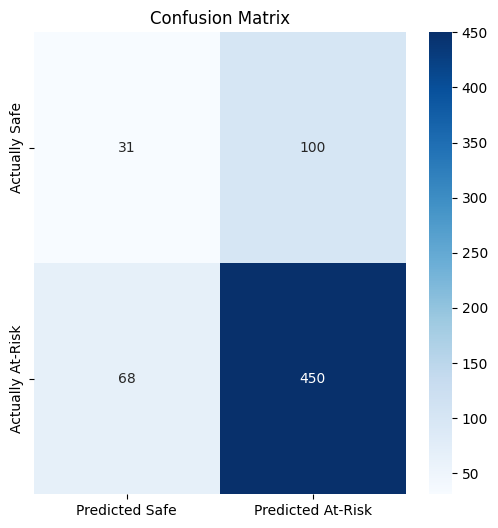

In [606]:
plt.figure(figsize=(6,6))
plt.title('Confusion Matrix')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Truth')
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Safe', 'Predicted At-Risk'], yticklabels=['Actually Safe', 'Actually At-Risk'])

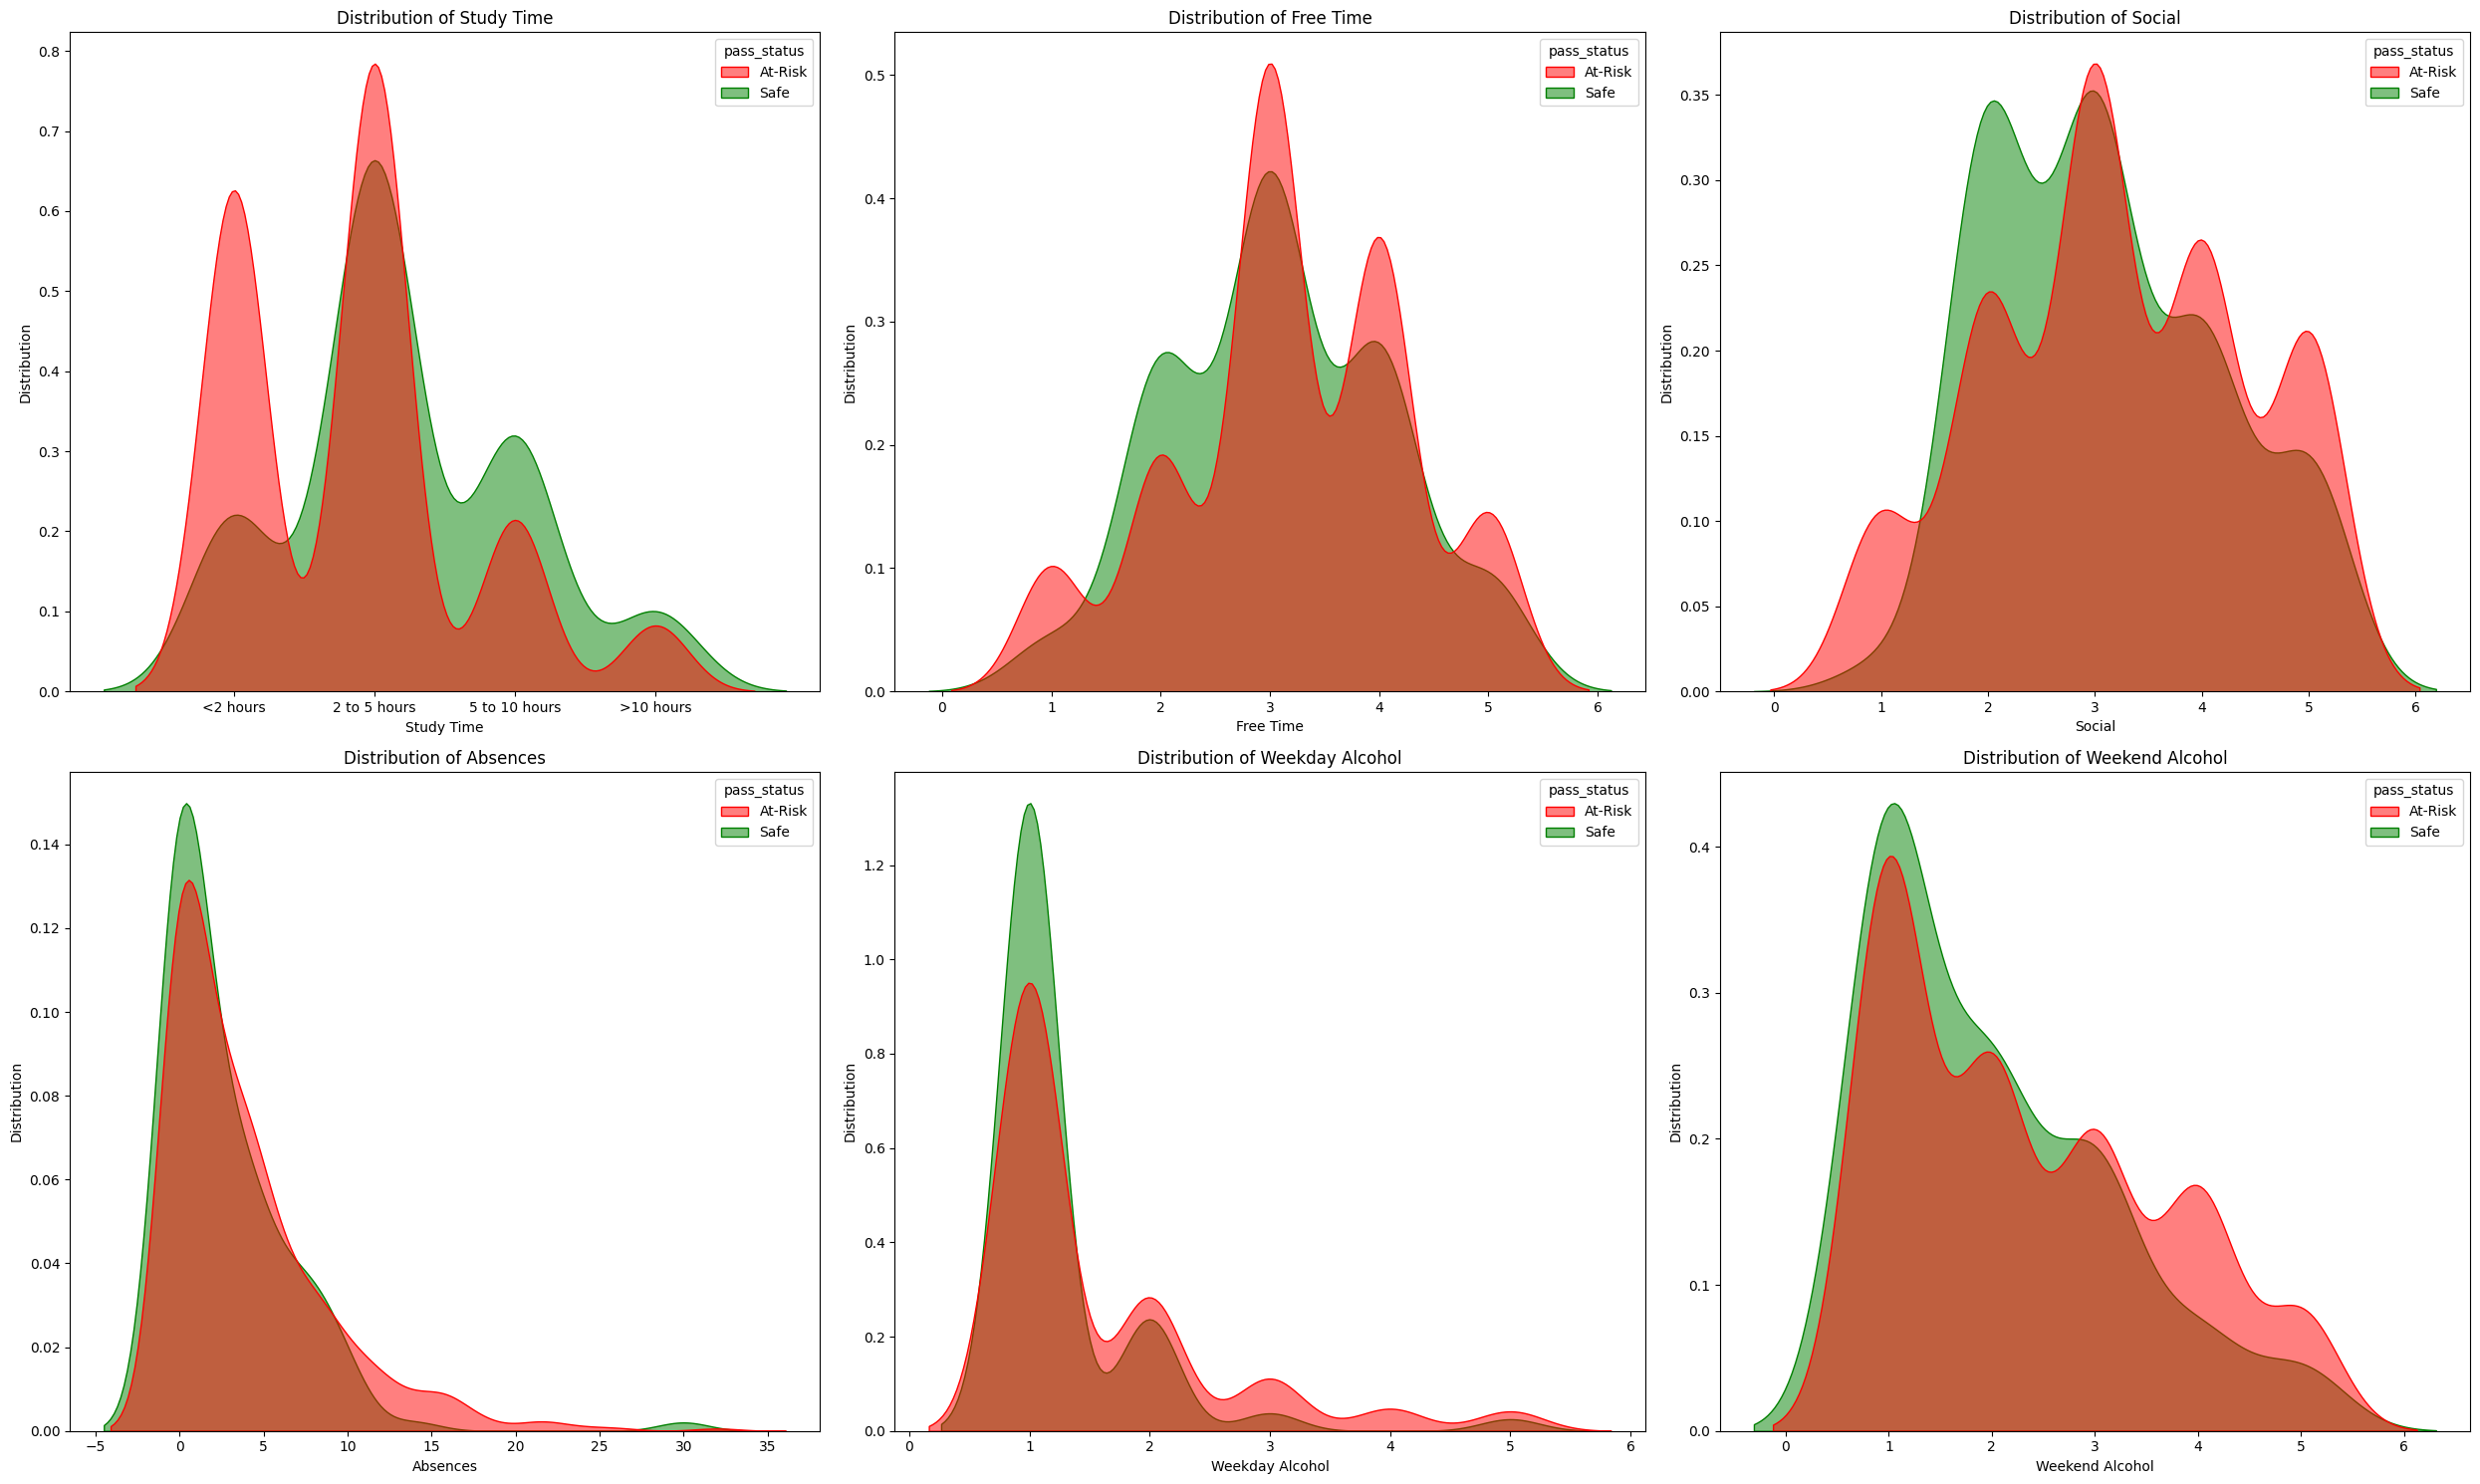

In [607]:
# Create a large figure to hold the plots
fig, axes = plt.subplots(2, 3, figsize=(25, 15))

# Diagram 1: Study Time
axes[0][0].set_title('Distribution of Study Time')
axes[0][0].set_xlabel("Study Time")
axes[0][0].set_ylabel("Distribution")
axes[0][0].set_xticks(list(study_time_mapper.mapping().keys()))
axes[0][0].set_xticklabels(list(study_time_mapper.mapping().values()))
sns.kdeplot(data=testing_data, x='study_time', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][0])

# Diagram 2: Free Time
axes[0][1].set_title('Distribution of Free Time')
axes[0][1].set_xlabel("Free Time")
axes[0][1].set_ylabel("Distribution")
sns.kdeplot(data=testing_data, x='free_time', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][1])

# Diagram 3: Social
axes[0][2].set_title('Distribution of Social')
axes[0][2].set_xlabel("Social")
axes[0][2].set_ylabel("Distribution")
sns.kdeplot(data=testing_data, x='social', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[0][2])

# Diagram 4: Absences
axes[1][0].set_title('Distribution of Absences')
axes[1][0].set_xlabel("Absences")
axes[1][0].set_ylabel("Distribution")
sns.kdeplot(data=testing_data, x='absences', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][0])

# Diagram 5: Weekday Alcohol
axes[1][1].set_title('Distribution of Weekday Alcohol')
axes[1][1].set_xlabel("Weekday Alcohol")
axes[1][1].set_ylabel("Distribution")
sns.kdeplot(data=testing_data, x='weekday_alcohol', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][1])

# Diagram 6: Weekend Alcohol
axes[1][2].set_title('Distribution of Weekend Alcohol')
axes[1][2].set_xlabel("Weekend Alcohol")
axes[1][2].set_ylabel("Distribution")
sns.kdeplot(data=testing_data, x='weekend_alcohol', hue='pass_status', fill=True, common_norm=False, palette={'Safe':'green', 'At-Risk':'red'}, alpha=0.5, ax=axes[1][2])

plt.tight_layout()
plt.show()